<a href="https://colab.research.google.com/github/ductin2197/PYTHON_CreditScoringModel/blob/main/ScoringTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import random

# Thiết lập seed để kết quả giả lập không bị thay đổi mỗi lần chạy
np.random.seed(42)
random.seed(42)

# Tạo 1000 khách hàng giả lập
n_customers = 1000

mock_data = {
    'Customer_ID': [f'MOMO_{i:04d}' for i in range(1, n_customers + 1)],
    'Account_Age_Months': np.random.randint(1, 48, size=n_customers),
    'Past_Due_Times': np.random.choice([0, 1, 2, 3, 4], size=n_customers, p=[0.7, 0.15, 0.08, 0.05, 0.02]),
    'Utility_Payment_Months': np.random.randint(0, 13, size=n_customers),
    'Monthly_Transaction_Volume': np.random.randint(0, 50) * 500000  # 0 đến 25 triệu VNĐ
}

# Chuyển thành DataFrame
df_customers = pd.DataFrame(mock_data)

# Xem 5 khách hàng đầu tiên
df_customers.head()

,Customer_ID,Account_Age_Months,Past_Due_Times,Utility_Payment_Months,Monthly_Transaction_Volume
0,MOMO_0001,39,0,5,9000000
1,MOMO_0002,29,1,12,9000000
2,MOMO_0003,15,0,10,9000000
3,MOMO_0004,43,0,1,9000000
4,MOMO_0005,8,1,11,9000000


In [10]:
def calculate_credit_score(row):
    # Điểm nền ban đầu (Base Score) là 500 điểm
    score = 500

    # 1. Xét thời gian dùng ví (Account_Age_Months)
    if row['Account_Age_Months'] >= 24:
        score += 50  # Dùng trên 2 năm: cộng 50 điểm
    elif row['Account_Age_Months'] >= 6:
        score += 20  # Dùng từ 6 tháng đến 2 năm: cộng 20 điểm
    else:
        score -= 25  # Người mới dưới 6 tháng: trừ 25 điểm

    # 2. Xét lịch sử trễ hạn (Past_Due_Times)
    if row['Past_Due_Times'] == 0:
        score += 60  # Chưa trễ hạn: cộng 60 điểm
    elif row['Past_Due_Times'] == 1:
        score -= 20  # Trễ 1 lần: trừ 20 điểm
    elif row['Past_Due_Times'] == 2:
        score -= 60  # Trễ 2 lần: trừ 60 điểm
    else:
        score -= 120  # Trễ từ 3 lần: trừ 120 điểm, việc này nhằm cô lập hoàn toàn nhóm này vào vùng REJECT

    # 3. Xét hành vi thanh toán hóa đơn (Alternative Data)
    if row['Utility_Payment_Months'] >= 10:
        score += 30   # Đều đặn gần như cả năm: cộng 30 điểm
    elif row['Utility_Payment_Months'] >= 6:
        score += 15   # Tương đối đều: cộng 15 điểm
    elif row['Utility_Payment_Months'] == 0:
        score += 0    # Không có data: không thưởng, không phạt
    else:
        score -= 20   # Có data nhưng không đều: trừ 20 điểm


    # 4. Xét tổng số tiền giao dịch qua ví mỗi tháng

    if row['Monthly_Transaction_Volume'] >= 10000000:
        score += 50   # Giao dịch nhiều, dòng tiền tốt
    elif row['Monthly_Transaction_Volume'] >= 3000000:
        score += 25   # Mức trung bình
    elif row['Monthly_Transaction_Volume'] == 0:
        score += 0    # Không có data
    else:
        score -= 15   # Tài khoản gần như không hoạt động

    # Giới hạn thang điểm trong khoảng từ 300 đến 850
    return max(300, min(850, score))

# Áp dụng hàm tính điểm cho toàn bộ tập dữ liệu giả lập
df_customers['Credit_Score'] = df_customers.apply(calculate_credit_score, axis=1)
df_customers.head()

,Customer_ID,Account_Age_Months,Past_Due_Times,Utility_Payment_Months,Monthly_Transaction_Volume,Credit_Score
0,MOMO_0001,39,0,5,9000000,615
1,MOMO_0002,29,1,12,9000000,585
2,MOMO_0003,15,0,10,9000000,635
3,MOMO_0004,43,0,1,9000000,615
4,MOMO_0005,8,1,11,9000000,555


In [11]:
def make_credit_decision(score):
    if score >= 600:
        return 'APPROVE', '10,000,000 VND'
    elif score >= 500:
        return 'APPROVE', '5,000,000 VND'
    else:
        return 'REJECT', '0 VND'

# Áp dụng quyết định
df_customers[['Decision', 'Max_Limit']] = df_customers['Credit_Score'].apply(lambda s: pd.Series(make_credit_decision(s)))
df_customers.head()

,Customer_ID,Account_Age_Months,Past_Due_Times,Utility_Payment_Months,Monthly_Transaction_Volume,Credit_Score,Decision,Max_Limit
0,MOMO_0001,39,0,5,9000000,615,APPROVE,"10,000,000 VND"
1,MOMO_0002,29,1,12,9000000,585,APPROVE,"5,000,000 VND"
2,MOMO_0003,15,0,10,9000000,635,APPROVE,"10,000,000 VND"
3,MOMO_0004,43,0,1,9000000,615,APPROVE,"10,000,000 VND"
4,MOMO_0005,8,1,11,9000000,555,APPROVE,"5,000,000 VND"


In [12]:
# 1. Thống kê tỷ lệ Quyết định (Decision)
print("--- TỶ LỆ PHÊ DUYỆT HẠN MỨC ---")
decision_counts = df_customers['Decision'].value_counts(normalize=True) * 100
print(decision_counts.map('{:.2f}%'.format))

print("\n--- PHÂN BỐ HẠN MỨC ĐƯỢC CẤP ---")
limit_counts = df_customers['Max_Limit'].value_counts()
print(limit_counts)

# 2. Thống kê mô tả về Điểm tín dụng (Credit Score)
print("\n--- THỐNG KÊ ĐIỂM TÍN DỤNG ---")
print(df_customers['Credit_Score'].describe()[['mean', 'min', 'max']])

--- TỶ LỆ PHÊ DUYỆT HẠN MỨC ---
Decision
APPROVE    87.30%
REJECT     12.70%
Name: proportion, dtype: object

--- PHÂN BỐ HẠN MỨC ĐƯỢC CẤP ---
Max_Limit
10,000,000 VND    518
5,000,000 VND     355
0 VND             127
Name: count, dtype: int64

--- THỐNG KÊ ĐIỂM TÍN DỤNG ---
mean    583.935
min     360.000
max     665.000
Name: Credit_Score, dtype: float64


In [13]:
print("\n--- KIỂM TRA CHÉO GIỮA QUYẾT ĐỊNH VÀ SỐ LẦN TRỄ HẠN ---")
cross_tab = pd.crosstab(df_customers['Past_Due_Times'], df_customers['Decision'])
print(cross_tab)


--- KIỂM TRA CHÉO GIỮA QUYẾT ĐỊNH VÀ SỐ LẦN TRỄ HẠN ---
Decision        APPROVE  REJECT
Past_Due_Times                 
0                   699       0
1                   128      13
2                    46      40
3                     0      52
4                     0      22


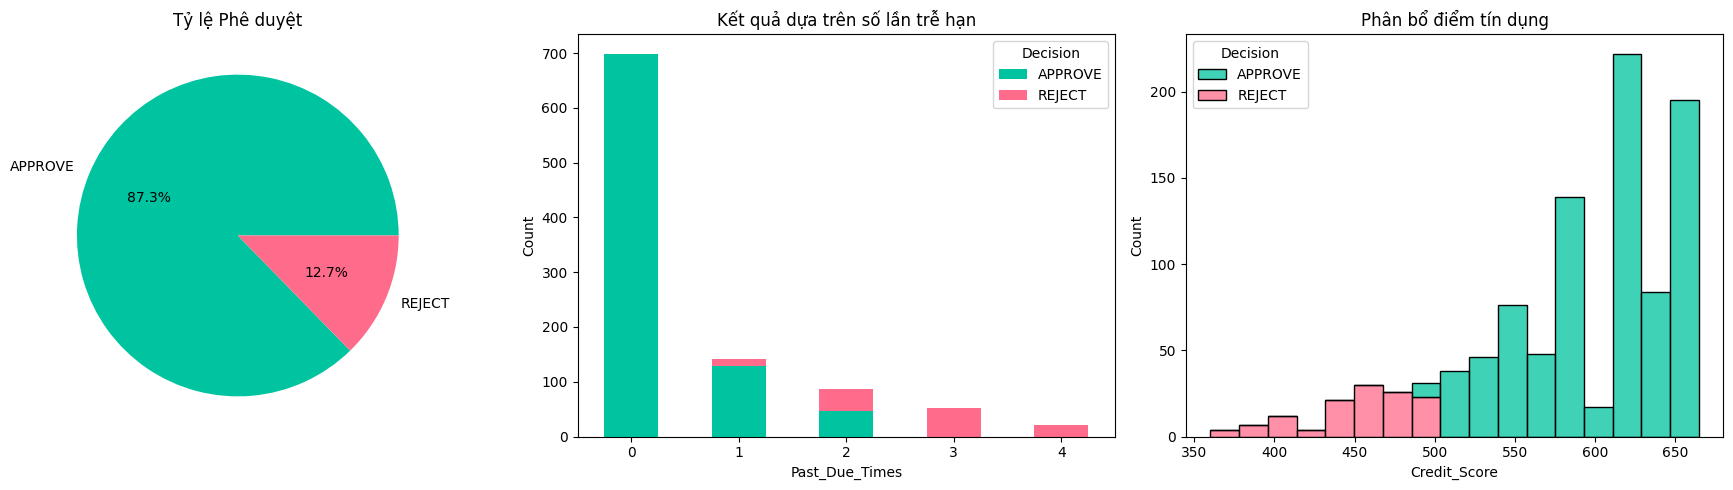

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Biểu đồ tròn (Tỷ lệ Duyệt / Từ chối)
df_customers['Decision'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#00C49F', '#FF6B8B'])
axes[0].set_ylabel('')
axes[0].set_title('Tỷ lệ Phê duyệt')

# 2. Biểu đồ cột (Trễ hạn càng nhiều, Reject càng cao)
pd.crosstab(df_customers['Past_Due_Times'], df_customers['Decision']).plot(kind='bar', stacked=True, ax=axes[1], color=['#00C49F', '#FF6B8B'], rot=0)
axes[1].set_ylabel('Count')
axes[1].set_title('Kết quả dựa trên số lần trễ hạn')

# 3. Biểu đồ phân phối điểm
sns.histplot(data=df_customers, x='Credit_Score', hue='Decision', ax=axes[2], palette=['#00C49F', '#FF6B8B'], multiple="stack")
axes[2].set_title('Phân bổ điểm tín dụng')

plt.tight_layout()
plt.show()